# Python Notebook 3: Regression Decision Trees & Ensemble Classifier
## 5DATA002W.2 – Machine Learning & Data Mining
**Author:** Viraj Jayasiri / w2153009  
**Code Peer Reviewer:** Maneth Liyanage  
**Peer Review Date:** 25/03/2026  
**Module:** 5DATA002W.2 – Machine Learning & Data Mining

---
This notebook contains:
1. **Ensemble Classifier** – Probability-based Voting Ensemble combining NB + LR base learners to predict Loan Approval Status
2. **Regression Decision Trees** – DT-1 (fully grown) and DT-2 (pruned, max_depth=4) to predict Maximum Loan Amount

## Code Reuse Session 3 – Task: Import Required Libraries
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [1]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical computations
import numpy as np

# Import matplotlib and seaborn for plots
import matplotlib.pyplot as plt
import seaborn as sns

# Import StandardScaler for feature normalisation
from sklearn.preprocessing import StandardScaler

# Import train_test_split for dataset splitting
from sklearn.model_selection import train_test_split

# Import the three base classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import VotingClassifier for the ensemble learner
from sklearn.ensemble import VotingClassifier

# Import DecisionTreeRegressor for regression modelling
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

# Import regression and classification evaluation metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

# Import warnings suppression
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


---
# PART A: Ensemble Classifier for Loan Approval Status Prediction

## Code Reuse Session 3 – Task: Load Classification Dataset and Prepare Train/Test Split
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [2]:
# Load Dataset A (prepared in Notebook 1) for ensemble classification
df_cls = pd.read_csv('/content/drive/MyDrive/k_ml/dataset_A_classification.csv')

# Define feature columns for classification
feature_names = [
    'age', 'income', 'home_ownership_enc', 'emplyment_length',
    'loan_intent_enc', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'payment_default_on_file', 'credit_history_length'
]

# Extract features and target
X_cls = df_cls[feature_names]
y_cls = df_cls['loan_approval_status']

# Apply StandardScaler for scaling (required for LR and NB)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cls)

# Split into train and test sets using same parameters as Notebook 2 for consistency
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print('Classification dataset loaded. Train:', X_train.shape, '| Test:', X_test.shape)

Classification dataset loaded. Train: (46913, 10) | Test: (11729, 10)


## Code Reuse Session 3 – Task: Rebuild Base Learners (NB and LR) for Ensemble
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [3]:
# Instantiate and train base learner 1: Naïve Bayes
nb_base = GaussianNB()
nb_base.fit(X_train, y_train)

# Instantiate and train base learner 2: Logistic Regression
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)

# Evaluate base learner 1: NB
y_pred_nb = nb_base.predict(X_test)
y_prob_nb = nb_base.predict_proba(X_test)[:, 1]

# Evaluate base learner 2: LR
y_pred_lr = lr_base.predict(X_test)
y_prob_lr = lr_base.predict_proba(X_test)[:, 1]

print('Base learners NB and LR trained successfully.')

Base learners NB and LR trained successfully.


## Code Reuse Session 3 – Task: Evaluate Base Learner 1 – NB (Confusion Matrix, Report, ROC)
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

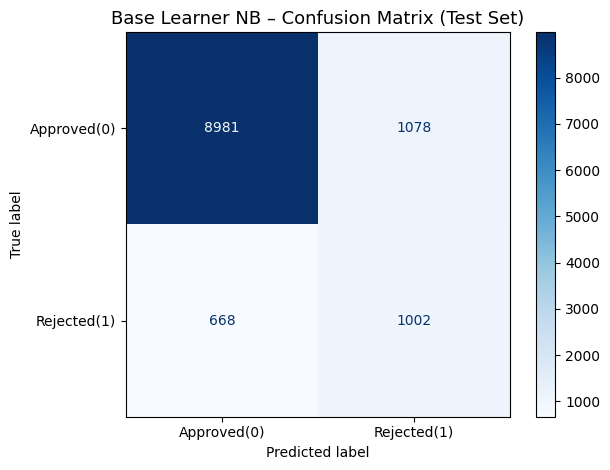

Base Learner NB – Classification Report:
              precision    recall  f1-score   support

 Approved(0)       0.93      0.89      0.91     10059
 Rejected(1)       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.71      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729



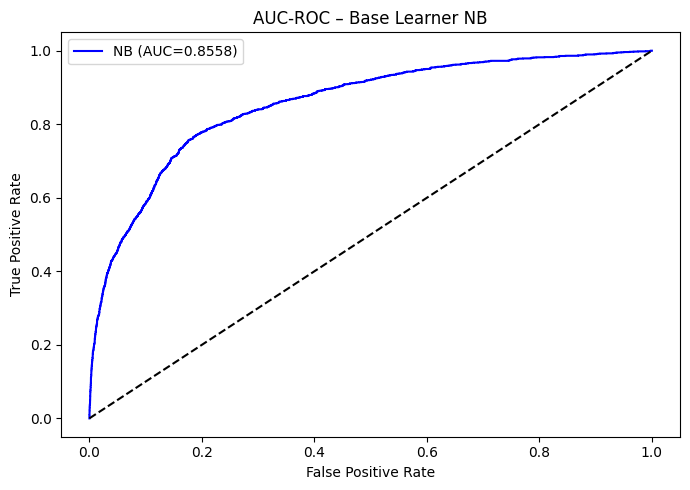

In [4]:
# Plot confusion matrix for base learner NB
cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=['Approved(0)', 'Rejected(1)']).plot(
    cmap='Blues')
plt.title('Base Learner NB – Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout(); plt.show()

print('Base Learner NB – Classification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Approved(0)', 'Rejected(1)']))

# ROC Curve for NB
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)
plt.figure(figsize=(7, 5))
plt.plot(fpr_nb, tpr_nb, label=f'NB (AUC={auc_nb:.4f})', color='blue')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('AUC-ROC – Base Learner NB'); plt.legend(); plt.tight_layout(); plt.show()

## Code Reuse Session 3 – Task: Evaluate Base Learner 2 – LR (Confusion Matrix, Report, ROC)
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

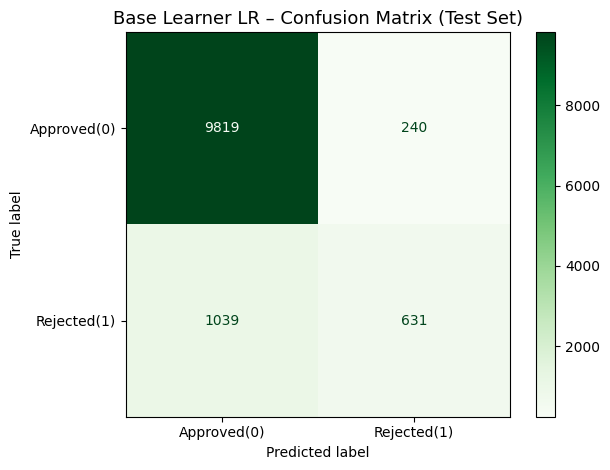

Base Learner LR – Classification Report:
              precision    recall  f1-score   support

 Approved(0)       0.90      0.98      0.94     10059
 Rejected(1)       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



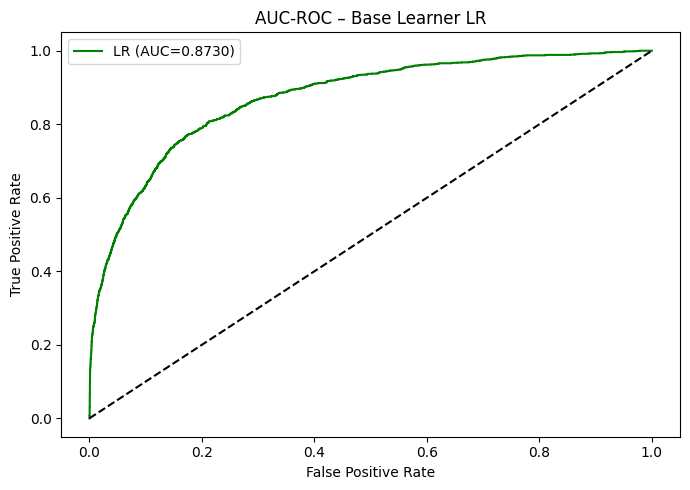

In [5]:
# Plot confusion matrix for base learner LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Approved(0)', 'Rejected(1)']).plot(
    cmap='Greens')
plt.title('Base Learner LR – Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout(); plt.show()

print('Base Learner LR – Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Approved(0)', 'Rejected(1)']))

# ROC Curve for LR
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC={auc_lr:.4f})', color='green')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('AUC-ROC – Base Learner LR'); plt.legend(); plt.tight_layout(); plt.show()

## Code Reuse Session 3 – Task: Build Probability-Based Voting Ensemble Classifier (NB + LR)
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [6]:
# Import VotingClassifier for ensemble learning
from sklearn.ensemble import VotingClassifier

# Declare the two base learners for the ensemble
base_learner_nb = GaussianNB()
base_learner_lr = LogisticRegression(max_iter=1000, random_state=42)

# Instantiate the probability-based soft voting ensemble classifier
# voting='soft' uses predicted class probabilities (averages them) for final prediction
ensemble = VotingClassifier(
    estimators=[
        ('nb', base_learner_nb),
        ('lr', base_learner_lr)
    ],
    voting='soft'
)

# Fit (train) the ensemble classifier on the training set
ensemble.fit(X_train, y_train)

print('Soft Voting Ensemble (NB + LR) trained successfully.')

Soft Voting Ensemble (NB + LR) trained successfully.


## Code Reuse Session 3 – Task: Evaluate the Ensemble Classifier
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

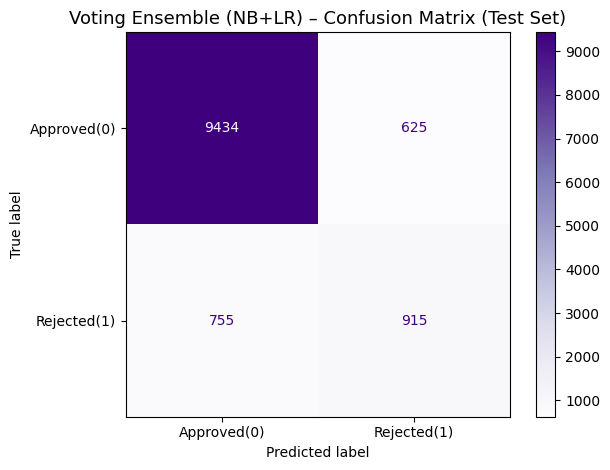

Voting Ensemble (NB+LR) – Classification Report:
              precision    recall  f1-score   support

 Approved(0)       0.93      0.94      0.93     10059
 Rejected(1)       0.59      0.55      0.57      1670

    accuracy                           0.88     11729
   macro avg       0.76      0.74      0.75     11729
weighted avg       0.88      0.88      0.88     11729



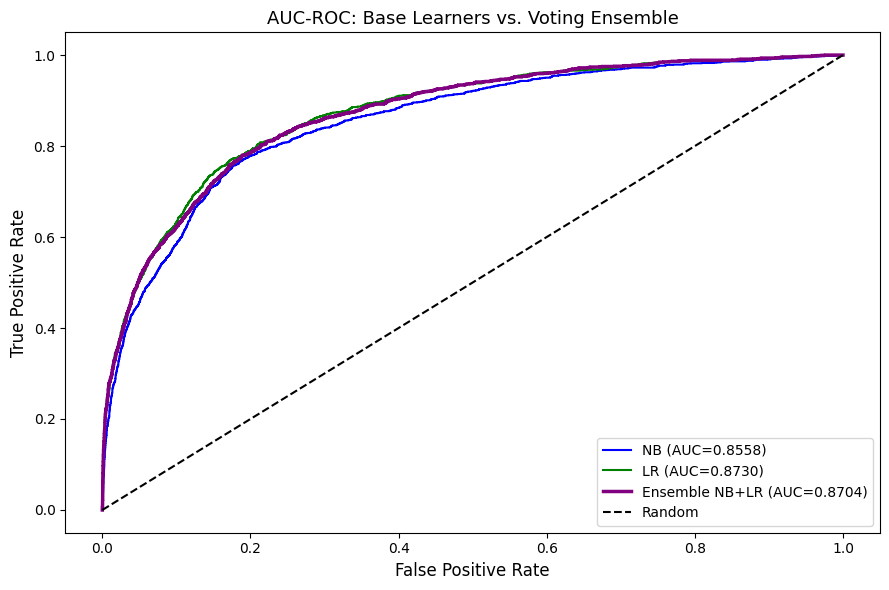


Performance Comparison: Base Learners vs Ensemble
NB         | Acc=0.8511 | Rec=0.6000 | Prec=0.4817 | AUC=0.8558
LR         | Acc=0.8910 | Rec=0.3778 | Prec=0.7245 | AUC=0.8730
Ensemble   | Acc=0.8823 | Rec=0.5479 | Prec=0.5942 | AUC=0.8704


In [7]:
# Generate predictions and probabilities from the ensemble classifier on the test set
y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]

# Plot confusion matrix for the ensemble
cm_ens = confusion_matrix(y_test, y_pred_ens)
ConfusionMatrixDisplay(cm_ens, display_labels=['Approved(0)', 'Rejected(1)']).plot(
    cmap='Purples')
plt.title('Voting Ensemble (NB+LR) – Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout(); plt.show()

# Print classification report for the ensemble
print('Voting Ensemble (NB+LR) – Classification Report:')
print(classification_report(y_test, y_pred_ens, target_names=['Approved(0)', 'Rejected(1)']))

# Plot ROC curves comparing base learners and ensemble
fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ens)
auc_ens = roc_auc_score(y_test, y_prob_ens)
plt.figure(figsize=(9, 6))
plt.plot(fpr_nb, tpr_nb, label=f'NB (AUC={auc_nb:.4f})', color='blue')
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC={auc_lr:.4f})', color='green')
plt.plot(fpr_ens, tpr_ens, label=f'Ensemble NB+LR (AUC={auc_ens:.4f})', color='purple', linewidth=2.5)
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AUC-ROC: Base Learners vs. Voting Ensemble', fontsize=13)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

# Summary table
print('\nPerformance Comparison: Base Learners vs Ensemble')
for name, y_p, y_prob in [('NB', y_pred_nb, y_prob_nb), ('LR', y_pred_lr, y_prob_lr), ('Ensemble', y_pred_ens, y_prob_ens)]:
    print(f"{name:10s} | Acc={accuracy_score(y_test,y_p):.4f} | Rec={recall_score(y_test,y_p):.4f} | Prec={precision_score(y_test,y_p):.4f} | AUC={roc_auc_score(y_test,y_prob):.4f}")

---
# PART B: Regression Decision Trees for Maximum Loan Amount Prediction

## Code Reuse Session 3 – Task: Load Regression Dataset and Prepare Train/Test Split
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [9]:
# Load Dataset B (approved clients only, prepared in Notebook 1) for regression
df_reg = pd.read_csv('/content/drive/MyDrive/k_ml/dataset_B_regression.csv')

# Define feature columns for regression
feat_reg = [
    'age', 'income', 'home_ownership_enc', 'emplyment_length',
    'loan_intent_enc', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'payment_default_on_file', 'credit_history_length'
]

# Extract features and target for regression
X_reg = df_reg[feat_reg]
y_reg = df_reg['max_allowed_loan']

# Print dataset dimensions (for Case Study B Task 1 evidence)
print('Regression Dataset Dimensions:', X_reg.shape)
print('Feature Names:', feat_reg)
print('Target Variable: max_allowed_loan')
print('\nTarget Descriptive Statistics:')
print(y_reg.describe())

# Split into train (80%) and test (20%) sets; random_state=42 for reproducibility
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print('\nTrain set:', X_train_r.shape, '| Test set:', X_test_r.shape)

Regression Dataset Dimensions: (50292, 10)
Feature Names: ['age', 'income', 'home_ownership_enc', 'emplyment_length', 'loan_intent_enc', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Target Variable: max_allowed_loan

Target Descriptive Statistics:
count    5.029200e+04
mean     8.139253e+04
std      5.812145e+04
min      2.320000e+02
25%      4.911050e+04
50%      6.943150e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64

Train set: (40233, 10) | Test set: (10059, 10)


## Code Reuse Session 3 – Task: Build DT-1 – Fully Grown Decision Tree Regressor
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [10]:
# Import DecisionTreeRegressor for regression modelling
from sklearn.tree import DecisionTreeRegressor

# Instantiate DT-1: fully grown decision tree regressor with no depth restriction
dt1 = DecisionTreeRegressor(random_state=42)

# Fit DT-1 on the training data
dt1.fit(X_train_r, y_train_r)

# Print the tree depth and number of leaves to characterise the fully grown tree
print('DT-1 (Fully Grown) – Tree Depth:', dt1.get_depth())
print('DT-1 (Fully Grown) – Number of Leaves:', dt1.get_n_leaves())

DT-1 (Fully Grown) – Tree Depth: 25
DT-1 (Fully Grown) – Number of Leaves: 22958


## Code Reuse Session 3 – Task: Build DT-2 – Pruned Decision Tree Regressor (max_depth=4)
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [11]:
# Instantiate DT-2: pruned decision tree regressor restricted to a maximum of 4 levels
# max_depth=4 performs pre-pruning (limiting tree growth during training)
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)

# Fit DT-2 on the training data
dt2.fit(X_train_r, y_train_r)

# Print the tree depth and number of leaves to characterise the pruned tree
print('DT-2 (Pruned, max_depth=4) – Tree Depth:', dt2.get_depth())
print('DT-2 (Pruned, max_depth=4) – Number of Leaves:', dt2.get_n_leaves())

DT-2 (Pruned, max_depth=4) – Tree Depth: 4
DT-2 (Pruned, max_depth=4) – Number of Leaves: 16


## Code Reuse Session 3 – Task: Visualise DT-1 (Fully Grown Decision Tree)
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

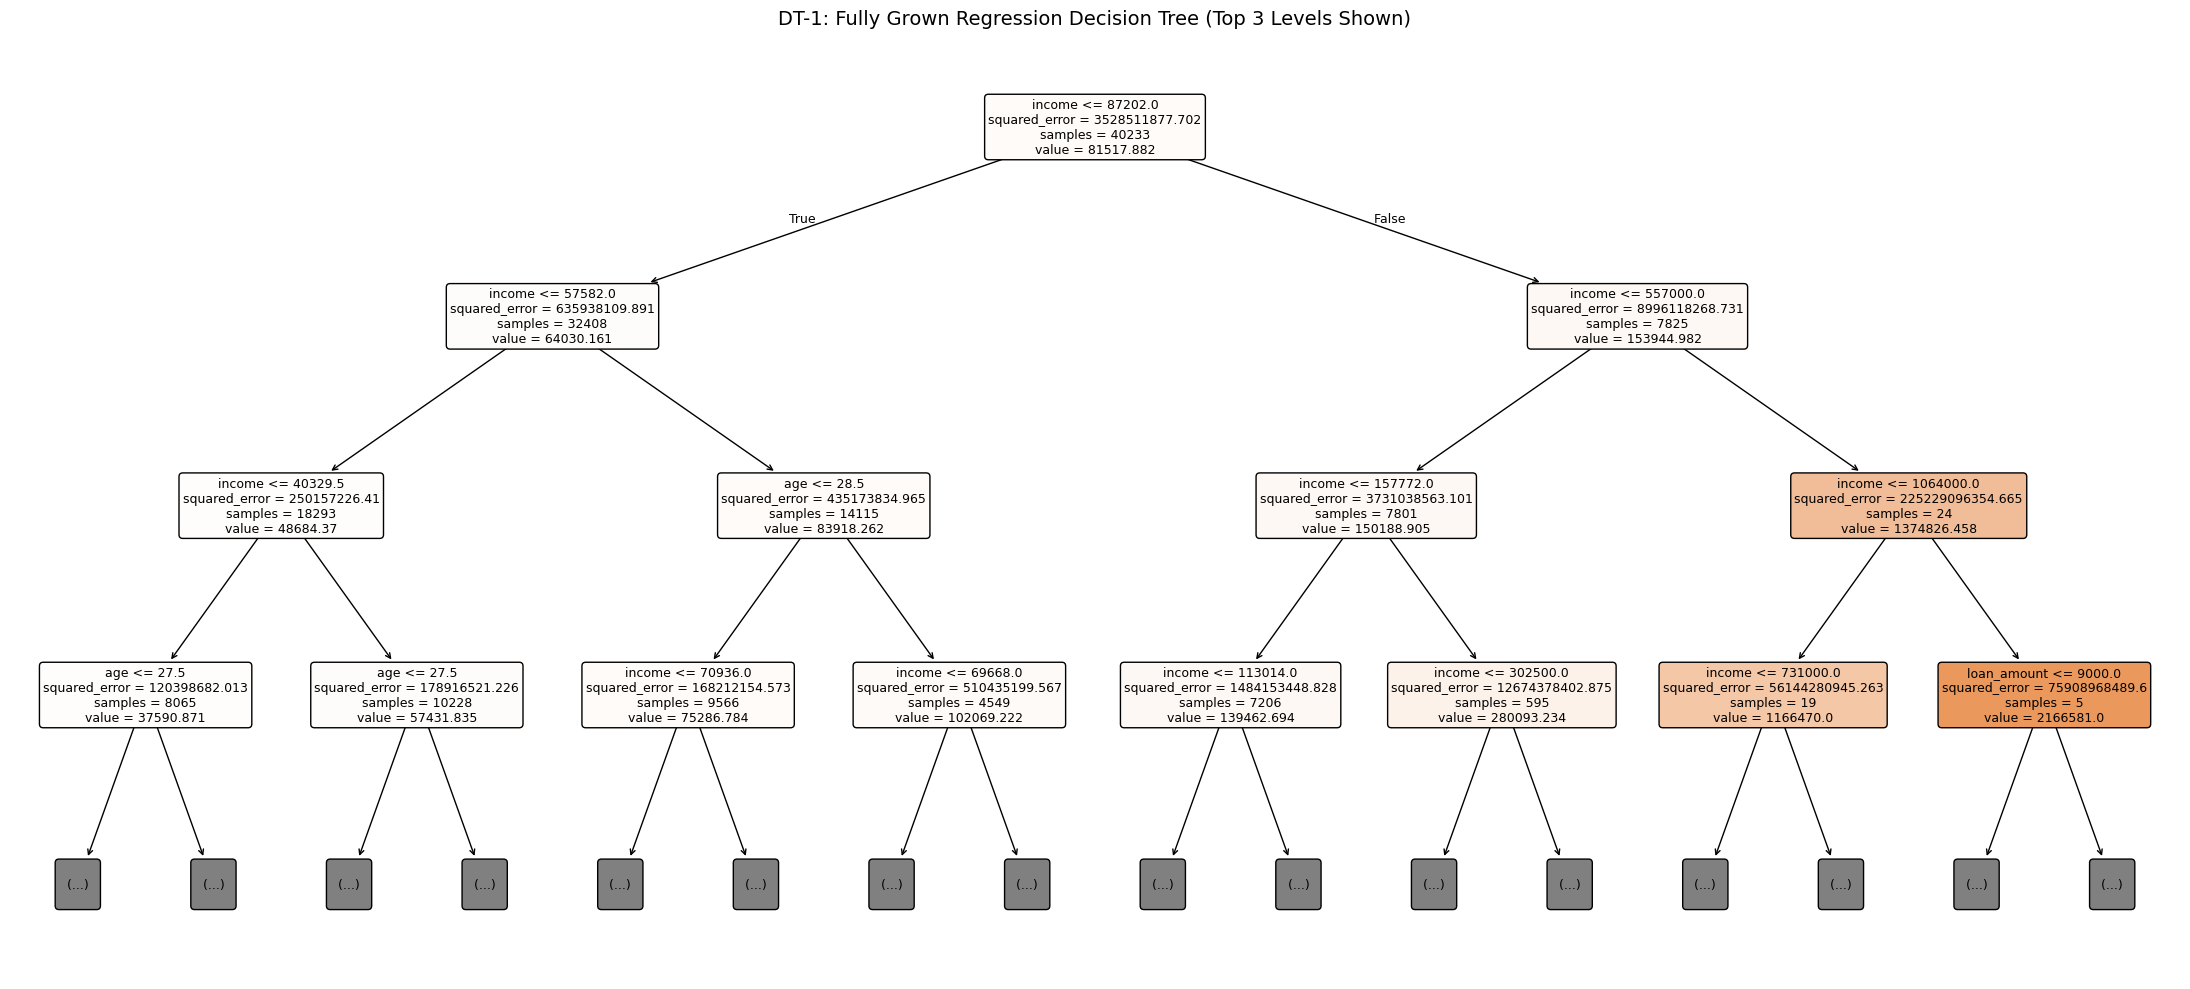

Note: DT-1 has depth=25 and 22958 leaves in total.


In [12]:
# Visualise DT-1 – only show first 3 levels for readability (tree is too large to display fully)
plt.figure(figsize=(22, 10))
plot_tree(
    dt1,
    max_depth=3,
    feature_names=feat_reg,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True
)
plt.title('DT-1: Fully Grown Regression Decision Tree (Top 3 Levels Shown)', fontsize=14)
plt.tight_layout()
plt.show()
print(f'Note: DT-1 has depth={dt1.get_depth()} and {dt1.get_n_leaves()} leaves in total.')

## Code Reuse Session 3 – Task: Visualise DT-2 (Pruned Decision Tree, max_depth=4)
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

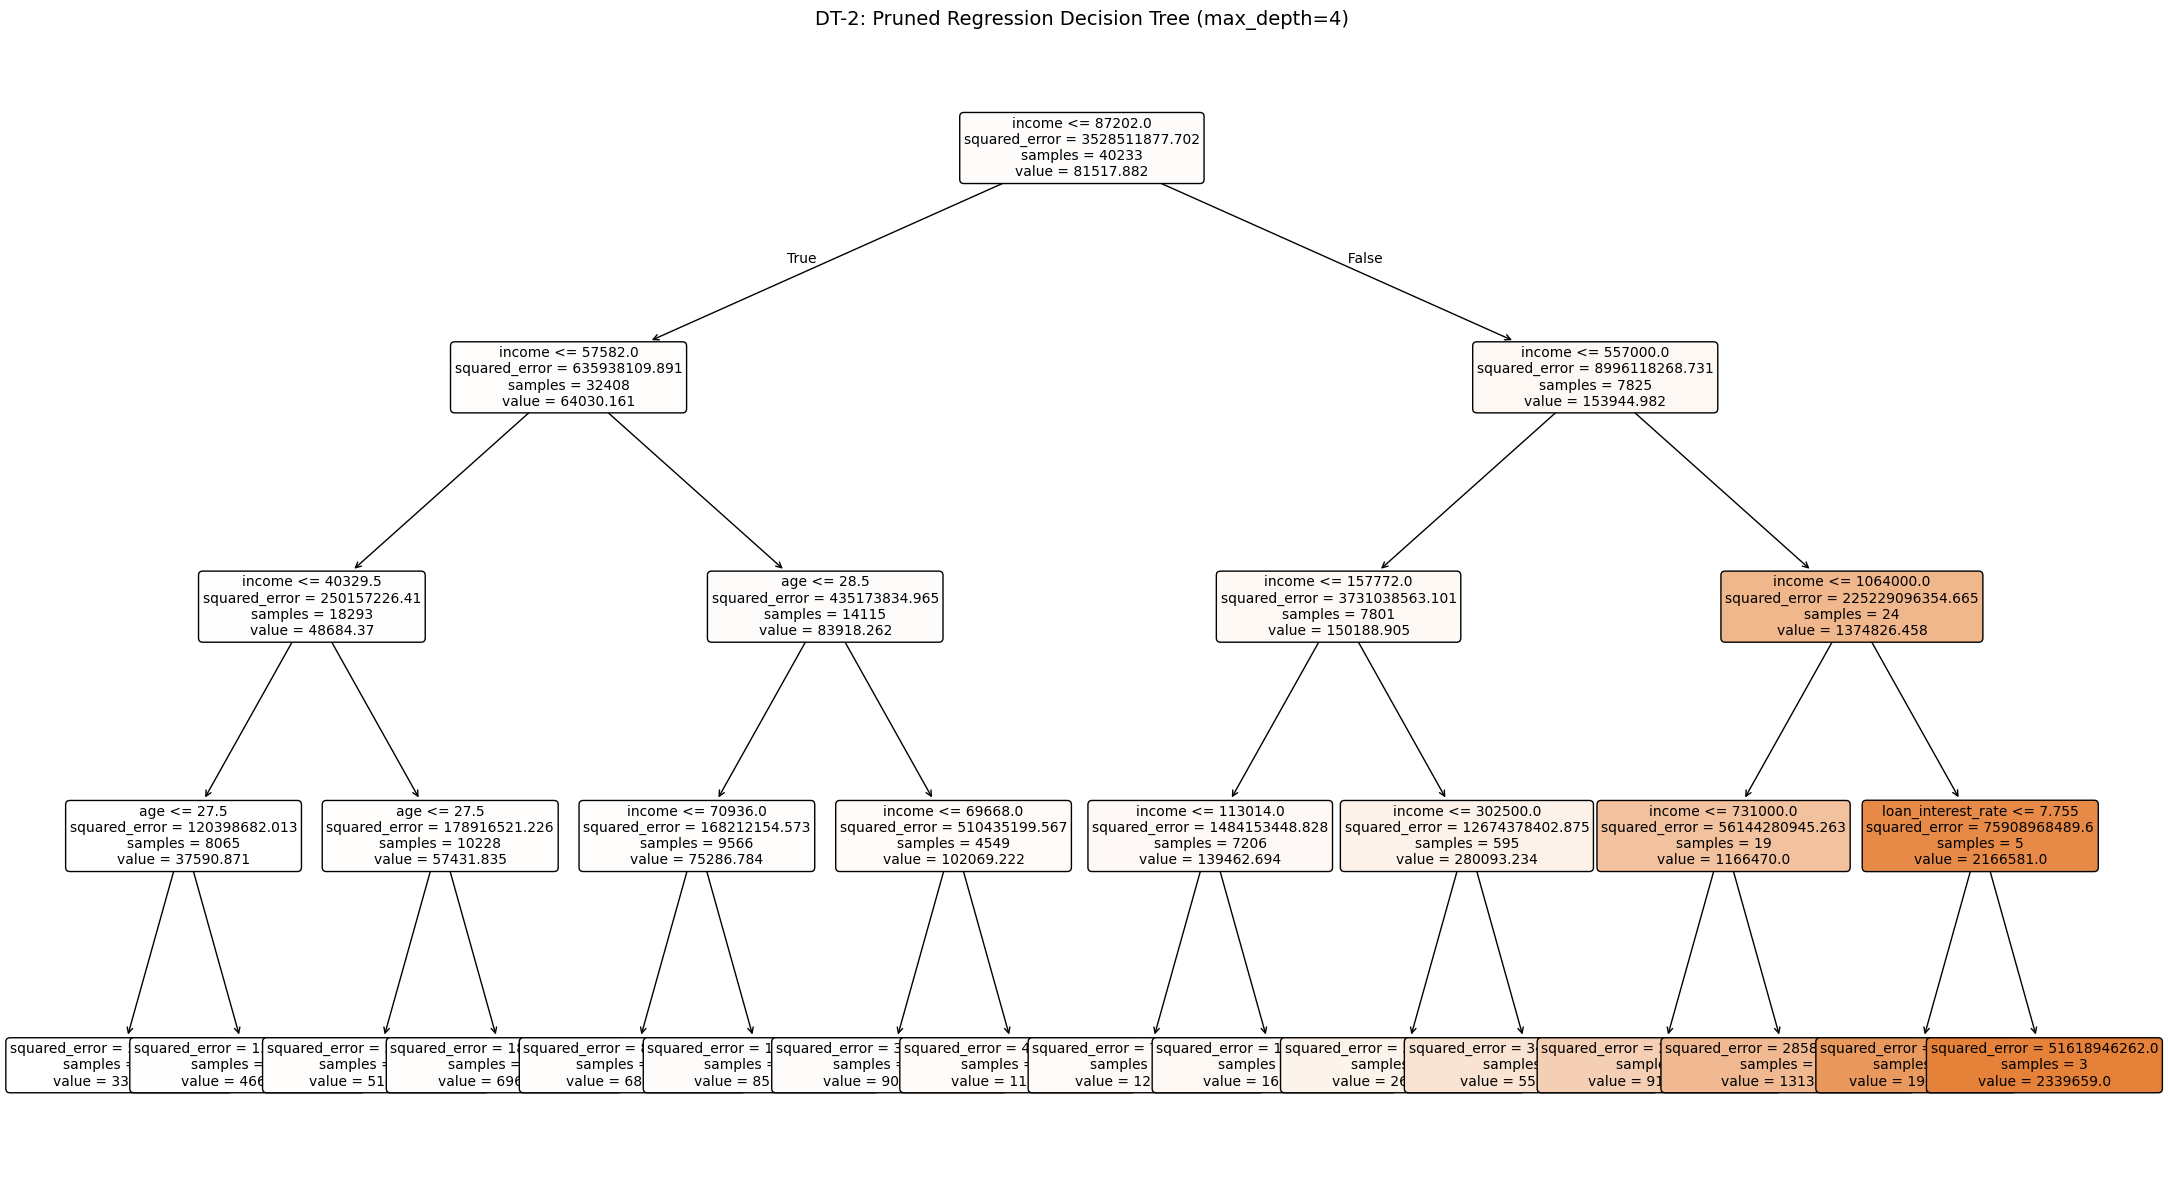

DT-2 has depth=4 and 16 leaves.


In [13]:
# Visualise DT-2 – fully displayed as it is pruned to only 4 levels
plt.figure(figsize=(22, 12))
plot_tree(
    dt2,
    feature_names=feat_reg,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True
)
plt.title('DT-2: Pruned Regression Decision Tree (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()
print(f'DT-2 has depth={dt2.get_depth()} and {dt2.get_n_leaves()} leaves.')

## Code Reuse Session 3 – Task: Evaluate DT-1 and DT-2 (MSE, MAE, R²)
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [14]:
# Generate predictions on the test set for both DT models
y_pred_dt1 = dt1.predict(X_test_r)
y_pred_dt2 = dt2.predict(X_test_r)

# Compute all three regression evaluation metrics for DT-1
mse_dt1 = mean_squared_error(y_test_r, y_pred_dt1)
mae_dt1 = mean_absolute_error(y_test_r, y_pred_dt1)
r2_dt1  = r2_score(y_test_r, y_pred_dt1)

# Compute all three regression evaluation metrics for DT-2
mse_dt2 = mean_squared_error(y_test_r, y_pred_dt2)
mae_dt2 = mean_absolute_error(y_test_r, y_pred_dt2)
r2_dt2  = r2_score(y_test_r, y_pred_dt2)

# Print regression performance metrics summary
print('Regression Evaluation Metrics – Test Set')
print('=' * 60)
print(f'{'Metric':<25} {'DT-1 (Full)':>15} {'DT-2 (Pruned)':>15}')
print('-' * 60)
print(f'{'MSE'::<25} {mse_dt1:>15,.2f} {mse_dt2:>15,.2f}')
print(f'{'RMSE'::<25} {np.sqrt(mse_dt1):>15,.2f} {np.sqrt(mse_dt2):>15,.2f}')
print(f'{'MAE'::<25} {mae_dt1:>15,.2f} {mae_dt2:>15,.2f}')
print(f'{'R-Squared (R²)'::<25} {r2_dt1:>15.4f} {r2_dt2:>15.4f}')

Regression Evaluation Metrics – Test Set
Metric                        DT-1 (Full)   DT-2 (Pruned)
------------------------------------------------------------
MSE::::::::::::::::::::::   47,716,744.05  374,722,938.77
RMSE:::::::::::::::::::::        6,907.73       19,357.76
MAE::::::::::::::::::::::        1,209.21       11,801.05
R-Squared (R²):::::::::::          0.9828          0.8650


## Code Reuse Session 3 – Task: Feature Importance Plot for DT-2
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

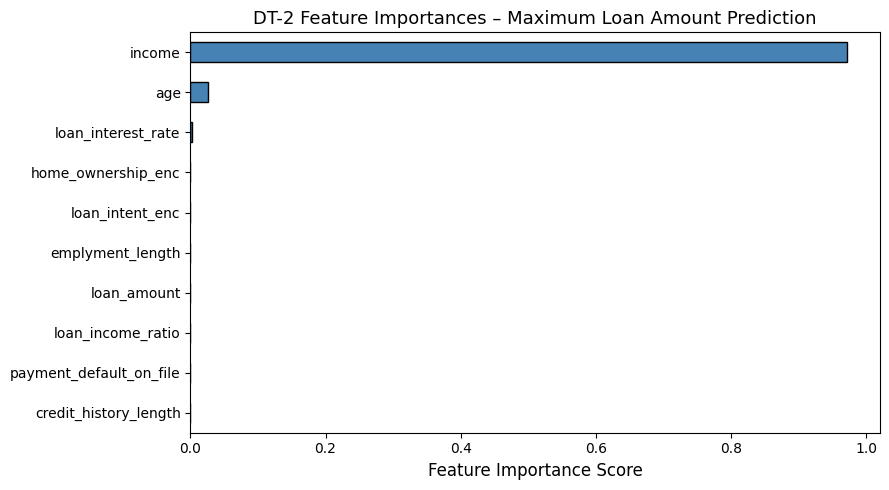

Feature Importances (DT-2):
income                     0.9716
age                        0.0266
loan_interest_rate         0.0018
home_ownership_enc         0.0000
loan_intent_enc            0.0000
emplyment_length           0.0000
loan_amount                0.0000
loan_income_ratio          0.0000
payment_default_on_file    0.0000
credit_history_length      0.0000
dtype: float64


In [15]:
# Extract feature importance scores from the pruned DT-2 model
fi = pd.Series(dt2.feature_importances_, index=feat_reg).sort_values(ascending=False)

# Plot feature importances as a horizontal bar chart
plt.figure(figsize=(9, 5))
fi.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('DT-2 Feature Importances – Maximum Loan Amount Prediction', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Feature Importances (DT-2):')
print(fi.round(4))

## Code Reuse Session 3 – Task: Predict Maximum Loan Amount for Client 60256
*(Leveraged and reused from Code Reuse Session 3, Week 9)*

In [16]:
# Define the attributes of Client 60256 as provided in the coursework specification
# Encoding: RENT=3, MEDICAL=3 (from LabelEncoder in Notebook 1)
client_60256 = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'home_ownership_enc': 3,       # RENT encoded as 3
    'emplyment_length': 15,
    'loan_intent_enc': 3,           # MEDICAL encoded as 3
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'payment_default_on_file': 0,  # N (No default) encoded as 0
    'credit_history_length': 35
}])

# Use DT-2 (pruned model) as selected best model to predict maximum loan amount
max_loan_pred_dt2 = dt2.predict(client_60256)[0]
max_loan_pred_dt1 = dt1.predict(client_60256)[0]

print('Prediction for Client 60256:')
print(f'  DT-1 (Fully Grown) predicted Maximum Loan Amount: £{max_loan_pred_dt1:,.0f}')
print(f'  DT-2 (Pruned)      predicted Maximum Loan Amount: £{max_loan_pred_dt2:,.0f}')
print('\nSelected Model for prediction: DT-2 (Pruned, max_depth=4)')
print(f'Estimated Maximum Loan Amount for Client 60256: £{max_loan_pred_dt2:,.0f}')

# Show the decision path taken by DT-2 for this client
decision_path = dt2.decision_path(client_60256)
print('\nDecision path node indicators (DT-2):', decision_path.toarray())

Prediction for Client 60256:
  DT-1 (Fully Grown) predicted Maximum Loan Amount: £80,501
  DT-2 (Pruned)      predicted Maximum Loan Amount: £69,664

Selected Model for prediction: DT-2 (Pruned, max_depth=4)
Estimated Maximum Loan Amount for Client 60256: £69,664

Decision path node indicators (DT-2): [[1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
